# Actividad 02 — 1: Feature Selection con Algoritmo Genético

**Objetivo asignado:** implementar un algoritmo genético para selección de características (*feature selection*) mostrando explícitamente: representación binaria, población inicial, función de aptitud, selección, cruzamiento, mutación, elitismo y terminación.

**Dataset:** Wine de `scikit-learn`  
**Modelo evaluador:** Regresión Logística  
**Entorno:** Google Colab / Jupyter

> El algoritmo genético no modifica el dataset. Prueba distintos subconjuntos de sus 13 características. Cada cromosoma usa `1` para seleccionar una característica y `0` para descartarla.

In [ ]:
#1. LIBRERÍAS Y SEMILLA
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Añadido para visualizaciones mejoradas
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Configuración visual global
sns.set_theme(style="whitegrid", palette="muted")

SEMILLA = 42
random.seed(SEMILLA)
np.random.seed(SEMILLA)
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 1. Carga y comprensión del dataset

`X` contiene las variables de entrada y `y` contiene la clase objetivo. Wine tiene **178 registros**, **13 características** y **3 clases**.

In [ ]:
#2. CARGA DEL DATASET
wine = load_wine()
X = wine.data
y = wine.target
nombres_caracteristicas = list(wine.feature_names)

print("Dimensión de X:", X.shape)
print("Número de clases:", len(np.unique(y)))
print("\nCaracterísticas:")
for i, nombre in enumerate(nombres_caracteristicas, start=1):
    print(f"{i:2d}. {nombre}")



Dimensión de X: (178, 13)
Número de clases: 3

Características:
 1. alcohol
 2. malic_acid
 3. ash
 4. alcalinity_of_ash
 5. magnesium
 6. total_phenols
 7. flavanoids
 8. nonflavanoid_phenols
 9. proanthocyanins
10. color_intensity
11. hue
12. od280/od315_of_diluted_wines
13. proline


In [ ]:
# Vista tabular para entender los datos
muestra = pd.DataFrame(X, columns=nombres_caracteristicas)
muestra["clase"] = y
display(muestra.head())

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,clase
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


## 2. Separación entrenamiento/prueba

El algoritmo genético trabaja con el conjunto de entrenamiento. El conjunto de prueba se reserva para evaluar, al final, la mejor selección encontrada.

In [ ]:
#3. DIVISIÓN DE DATOS
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=SEMILLA
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (133, 13)
Prueba: (45, 13)


## 3. Representación binaria del cromosoma

Cada individuo tiene 13 genes, uno por característica:

- `1` = se usa la característica.
- `0` = se descarta.

Individuo 1: [0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0] -> selecciona 2 características
Individuo 2: [0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0] -> selecciona 6 características
Individuo 3: [0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1] -> selecciona 7 características
Individuo 4: [0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1] -> selecciona 5 características
Individuo 5: [1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1] -> selecciona 7 características


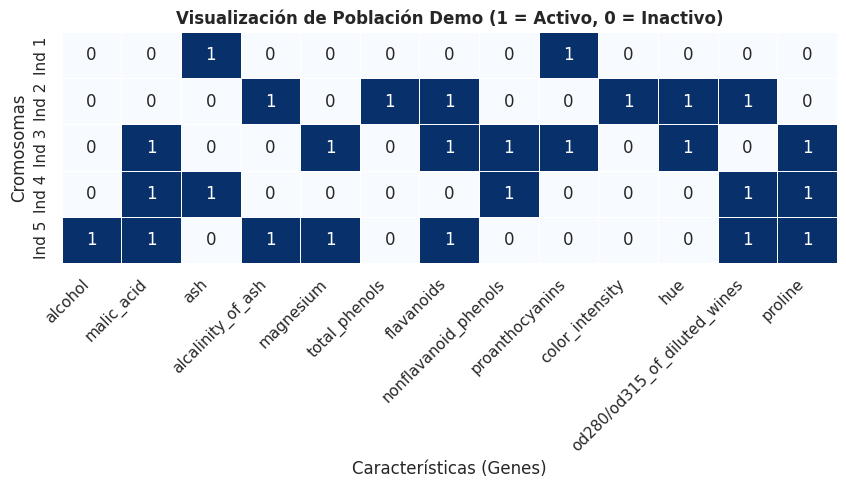

In [ ]:
#4. CREACIÓN DE INDIVIDUOS Y POBLACIÓN
def crear_individuo(numero_genes):
    """Crea un cromosoma binario aleatorio y garantiza al menos una característica activa."""
    individuo = [random.randint(0, 1) for _ in range(numero_genes)]
    if sum(individuo) == 0:
        individuo[random.randrange(numero_genes)] = 1
    return individuo

def crear_poblacion(tamano_poblacion, numero_genes):
    """Crea una lista de individuos."""
    return [crear_individuo(numero_genes) for _ in range(tamano_poblacion)]

poblacion_demo = crear_poblacion(5, X_train.shape[1])

for i, individuo in enumerate(poblacion_demo, start=1):
    print(f"Individuo {i}: {individuo} -> selecciona {sum(individuo)} características")

# MEJORA VISUAL: Mapa de calor para explicar la población inicial
df_pob = pd.DataFrame(poblacion_demo, columns=nombres_caracteristicas)
df_pob.index = [f"Ind {i}" for i in range(1, 6)]

plt.figure(figsize=(10, 3))
sns.heatmap(df_pob, cmap="Blues", linewidths=.5, cbar=False, annot=True)
plt.title("Visualización de Población Demo (1 = Activo, 0 = Inactivo)", fontweight='bold')
plt.xlabel("Características (Genes)")
plt.ylabel("Cromosomas")
plt.xticks(rotation=45, ha='right')
plt.show()

## 4. Función de aptitud (fitness)

Para evaluar un cromosoma se conservan solo las columnas marcadas con `1`, se entrena una Regresión Logística y se calcula el `accuracy` promedio mediante validación cruzada estratificada de 3 particiones.

La función utilizada es:

`fitness = accuracy_CV - 0.01 × (características seleccionadas / 13)`

La penalización es pequeña y favorece soluciones compactas cuando el rendimiento es parecido.

In [ ]:
#5. FUNCIÓN FITNESS
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEMILLA)

def calcular_fitness(individuo):
    mascara = np.array(individuo, dtype=bool)
    if mascara.sum() == 0:
        return -1.0

    X_seleccionado = X_train[:, mascara]
    modelo = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=2000, random_state=SEMILLA)
    )

    accuracy_cv = cross_val_score(
        modelo,
        X_seleccionado,
        y_train,
        cv=cv,
        scoring="accuracy"
    ).mean()

    penalizacion = 0.01 * (mascara.sum() / len(mascara))
    return accuracy_cv - penalizacion

individuo_prueba = crear_individuo(X_train.shape[1])
print("Individuo:", individuo_prueba)
print("Características:", sum(individuo_prueba))
print("Fitness:", round(calcular_fitness(individuo_prueba), 4))

Individuo: [1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0]
Características: 6
Fitness: 0.9126


## 5. Selección por torneo

Se toman 3 individuos al azar y se elige como padre el que tenga mayor fitness.

In [ ]:
#6. SELECCIÓN POR TORNEO
def seleccion_torneo(poblacion, fitnesses, tamano_torneo=3):
    participantes = random.sample(range(len(poblacion)), tamano_torneo)
    ganador = max(participantes, key=lambda i: fitnesses[i])
    return poblacion[ganador].copy()

## 6. Cruzamiento uniforme

Dos padres intercambian genes. Cada posición tiene 50% de probabilidad de intercambiarse.

In [ ]:
#7. CRUZAMIENTO UNIFORME
def cruce_uniforme(padre1, padre2, prob_intercambio=0.5):
    hijo1 = padre1.copy()
    hijo2 = padre2.copy()
    for i in range(len(padre1)):
        if random.random() < prob_intercambio:
            hijo1[i], hijo2[i] = hijo2[i], hijo1[i]
    return hijo1, hijo2

## 7. Mutación binaria

Cada gen tiene una pequeña probabilidad de cambiar `0→1` o `1→0`. La mutación aporta diversidad.

In [ ]:
#8. MUTACIÓN BINARIA
def mutacion(individuo, prob_mutacion=0.08):
    mutado = individuo.copy()
    for i in range(len(mutado)):
        if random.random() < prob_mutacion:
            mutado[i] = 1 - mutado[i]
    if sum(mutado) == 0:
        mutado[random.randrange(len(mutado))] = 1
    return mutado

## 8. Algoritmo genético completo

- Población: 12 individuos.
- Generaciones: 12.
- Probabilidad de cruce: 0.90.
- Probabilidad de mutación: 0.08 por gen.
- Selección: torneo.
- Crossover: uniforme.
- Elitismo: se conserva el mejor individuo.
- Terminación: 12 generaciones.

In [ ]:
#9. ALGORITMO GENÉTICO COMPLETO
def algoritmo_genetico_feature_selection(
    tamano_poblacion=12,
    generaciones=12,
    prob_cruce=0.90,
    prob_mutacion=0.08
):
    random.seed(SEMILLA)
    numero_genes = X_train.shape[1]
    poblacion = crear_poblacion(tamano_poblacion, numero_genes)
    historial = []

    print("INICIO DEL ALGORITMO GENÉTICO")
    print("-" * 78)

    for generacion in range(1, generaciones + 1):
        fitnesses = [calcular_fitness(ind) for ind in poblacion]

        indice_mejor = int(np.argmax(fitnesses))
        mejor_individuo = poblacion[indice_mejor].copy()
        mejor_fitness = fitnesses[indice_mejor]
        promedio_fitness = float(np.mean(fitnesses))

        historial.append({
            "generacion": generacion,
            "mejor_fitness": mejor_fitness,
            "fitness_promedio": promedio_fitness,
            "caracteristicas": sum(mejor_individuo)
        })

        print(
            f"Generación {generacion:02d} | "
            f"Mejor fitness: {mejor_fitness:.4f} | "
            f"Promedio: {promedio_fitness:.4f} | "
            f"Características: {sum(mejor_individuo)}"
        )

        # Elitismo
        nueva_poblacion = [mejor_individuo]

        # Selección, cruce, mutación
        while len(nueva_poblacion) < tamano_poblacion:
            padre1 = seleccion_torneo(poblacion, fitnesses)
            padre2 = seleccion_torneo(poblacion, fitnesses)

            if random.random() < prob_cruce:
                hijo1, hijo2 = cruce_uniforme(padre1, padre2)
            else:
                hijo1, hijo2 = padre1.copy(), padre2.copy()

            hijo1 = mutacion(hijo1, prob_mutacion)
            hijo2 = mutacion(hijo2, prob_mutacion)

            nueva_poblacion.extend([hijo1, hijo2])

        poblacion = nueva_poblacion[:tamano_poblacion]

    fitnesses_finales = [calcular_fitness(ind) for ind in poblacion]
    indice_mejor = int(np.argmax(fitnesses_finales))

    return (
        poblacion[indice_mejor],
        fitnesses_finales[indice_mejor],
        pd.DataFrame(historial)
    )

mejor_cromosoma, mejor_fitness, historial = algoritmo_genetico_feature_selection()

INICIO DEL ALGORITMO GENÉTICO
------------------------------------------------------------------------------
Generación 01 | Mejor fitness: 0.9504 | Promedio: 0.8930 | Características: 6
Generación 02 | Mejor fitness: 0.9656 | Promedio: 0.9422 | Características: 6
Generación 03 | Mejor fitness: 0.9724 | Promedio: 0.9538 | Características: 7
Generación 04 | Mejor fitness: 0.9887 | Promedio: 0.9568 | Características: 5
Generación 05 | Mejor fitness: 0.9887 | Promedio: 0.9521 | Características: 5
Generación 06 | Mejor fitness: 0.9887 | Promedio: 0.9612 | Características: 5
Generación 07 | Mejor fitness: 0.9887 | Promedio: 0.9698 | Características: 5
Generación 08 | Mejor fitness: 0.9887 | Promedio: 0.9764 | Características: 5
Generación 09 | Mejor fitness: 0.9887 | Promedio: 0.9748 | Características: 5
Generación 10 | Mejor fitness: 0.9887 | Promedio: 0.9786 | Características: 5
Generación 11 | Mejor fitness: 0.9887 | Promedio: 0.9754 | Características: 5
Generación 12 | Mejor fitness: 0.

## 9. Decodificación y evaluación final

El cromosoma se traduce a nombres de características. Luego se entrena el modelo final y se evalúa con el conjunto de prueba reservado.


------------------------------------------------------------------------------
MEJOR SOLUCIÓN ENCONTRADA
------------------------------------------------------------------------------
Cromosoma: [1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1]
Número de características seleccionadas: 5 de 13

Características seleccionadas:
- alcohol
- ash
- flavanoids
- hue
- proline

Fitness final: 0.9887
Accuracy en prueba con selección AG: 1.0000
Accuracy en prueba usando las 13 características: 1.0000


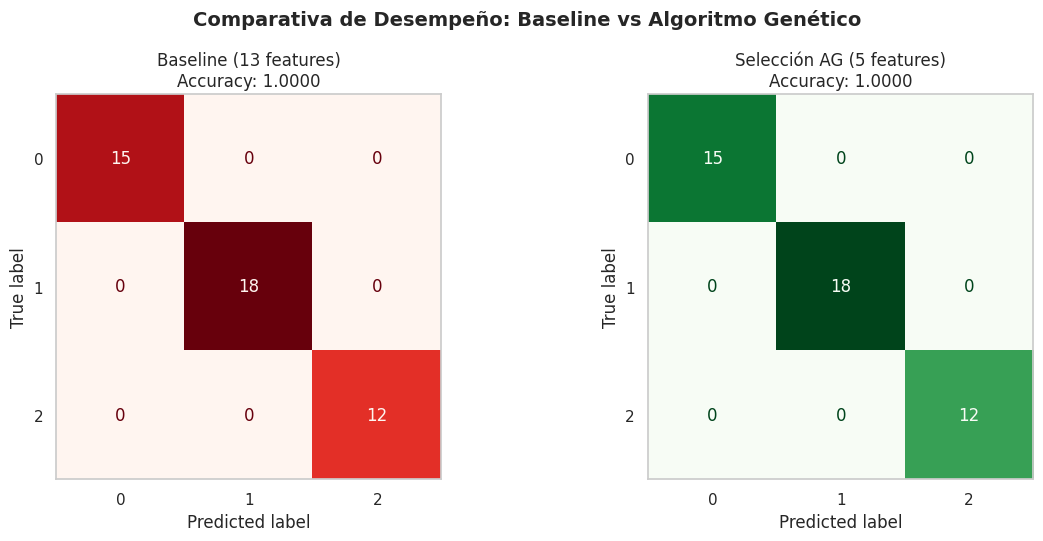

In [ ]:
#10. RESULTADO Y EVALUACIÓN FINAL
mascara = np.array(mejor_cromosoma, dtype=bool)
caracteristicas_seleccionadas = [
    nombre for nombre, usar in zip(nombres_caracteristicas, mejor_cromosoma) if usar
]

# Modelo final con AG
modelo_final = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, random_state=SEMILLA)
)
modelo_final.fit(X_train[:, mascara], y_train)
predicciones = modelo_final.predict(X_test[:, mascara])
accuracy_final = accuracy_score(y_test, predicciones)

# Línea base usando las 13 características
modelo_todas = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, random_state=SEMILLA)
)
modelo_todas.fit(X_train, y_train)
predicciones_todas = modelo_todas.predict(X_test)
accuracy_todas = accuracy_score(y_test, predicciones_todas)

print("\n" + "-" * 78)
print("MEJOR SOLUCIÓN ENCONTRADA")
print("-" * 78)
print("Cromosoma:", mejor_cromosoma)
print("Número de características seleccionadas:", len(caracteristicas_seleccionadas), "de", X.shape[1])
print("\nCaracterísticas seleccionadas:")
for nombre in caracteristicas_seleccionadas:
    print("-", nombre)

print(f"\nFitness final: {mejor_fitness:.4f}")
print(f"Accuracy en prueba con selección AG: {accuracy_final:.4f}")
print(f"Accuracy en prueba usando las 13 características: {accuracy_todas:.4f}")

# MEJORA VISUAL: Matrices de confusión comparativas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(y_test, predicciones_todas, ax=axes[0], cmap="Reds", colorbar=False)
axes[0].set_title(f"Baseline (13 features)\nAccuracy: {accuracy_todas:.4f}")
axes[0].grid(False)

ConfusionMatrixDisplay.from_predictions(y_test, predicciones, ax=axes[1], cmap="Greens", colorbar=False)
axes[1].set_title(f"Selección AG ({len(caracteristicas_seleccionadas)} features)\nAccuracy: {accuracy_final:.4f}")
axes[1].grid(False)

plt.suptitle("Comparativa de Desempeño: Baseline vs Algoritmo Genético", fontsize=14, fontweight='bold', y=1.05)
plt.show()

## 10. Curva de evolución

La gráfica muestra el mejor fitness y el fitness promedio de cada generación.

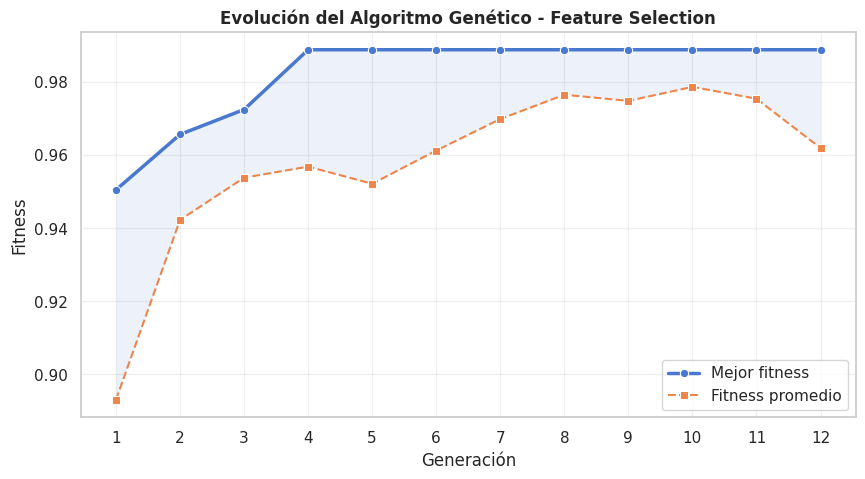

In [ ]:
#11. GRÁFICA DE EVOLUCIÓN
# MEJORA VISUAL: Gráfica enriquecida con área sombreada
plt.figure(figsize=(10, 5))
sns.lineplot(data=historial, x="generacion", y="mejor_fitness", marker="o", label="Mejor fitness", linewidth=2.5)
sns.lineplot(data=historial, x="generacion", y="fitness_promedio", marker="s", label="Fitness promedio", linestyle="--")
plt.fill_between(historial["generacion"], historial["fitness_promedio"], historial["mejor_fitness"], alpha=0.1)

plt.xlabel("Generación")
plt.ylabel("Fitness")
plt.title("Evolución del Algoritmo Genético - Feature Selection", fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(range(1, 13))
plt.show()

# Algoritmo Genético para Optimización de Hiperparámetros (Hyperparameter Optimization)


Este notebook implementa un **Algoritmo Genético (AG)** para encontrar la mejor combinación de hiperparámetros de un modelo `RandomForestClassifier` de `scikit-learn`, usando el dataset **Breast Cancer Wisconsin**.

El cromosoma combina **representación entera y continua** (mixta):

| Gen | Hiperparámetro | Tipo | Rango |
|---|---|---|---|
| 0 | `n_estimators` | Entero | [10, 200] |
| 1 | `max_depth` | Entero | [2, 20] |
| 2 | `min_samples_split` | Entero | [2, 10] |
| 3 | `min_samples_leaf` | Entero | [1, 10] |
| 4 | `max_features` | Continuo | [0.1, 1.0] |
| 5 | `criterion` | Entero (categórico codificado) | {0: gini, 1: entropy} |

La **función de aptitud (fitness)** es el `accuracy` promedio obtenido con validación cruzada (`cross_val_score`, k=5) usando esos hiperparámetros.


In [ ]:
# Librerías necesarias (ya vienen instaladas en Google Colab)
import numpy as np
import random
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

random.seed(42)
np.random.seed(42)


## 1. Datos

Usamos el dataset `Breast Cancer Wisconsin` incluido en scikit-learn: 569 muestras, 30 características numéricas, clasificación binaria (maligno / benigno).


In [ ]:
data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (426, 30)  Test: (143, 30)


## 2. Definición del espacio de búsqueda (representación del cromosoma)

Cada **individuo (cromosoma)** es un vector de 6 genes. Los primeros 4 y el último son enteros, el quinto (`max_features`) es continuo. Esto es lo que en el enunciado se pide como **representación entera/continua**.


In [ ]:
# Límites (min, max) de cada gen
GENE_BOUNDS = [
    (10, 200),   # n_estimators (entero)
    (2, 20),     # max_depth (entero)
    (2, 10),     # min_samples_split (entero)
    (1, 10),     # min_samples_leaf (entero)
    (0.1, 1.0),  # max_features (continuo)
    (0, 1),      # criterion: 0=gini, 1=entropy (entero categórico)
]

GENE_TYPES = ["int", "int", "int", "int", "float", "int"]
CRITERION_MAP = {0: "gini", 1: "entropy"}

N_GENES = len(GENE_BOUNDS)


## 3. Inicialización de la población

Se genera una población inicial de individuos aleatorios, respetando el tipo (entero o continuo) y los límites de cada gen.


In [ ]:
def create_individual():
    """Crea un cromosoma aleatorio respetando tipo y rango de cada gen."""
    individual = []
    for (low, high), gtype in zip(GENE_BOUNDS, GENE_TYPES):
        if gtype == "int":
            gene = random.randint(low, high)
        else:
            gene = random.uniform(low, high)
        individual.append(gene)
    return individual


def create_population(pop_size):
    return [create_individual() for _ in range(pop_size)]


## 4. Función de aptitud (Fitness)

Decodifica el cromosoma a un diccionario de hiperparámetros válidos para `RandomForestClassifier`, entrena con validación cruzada (5-fold) sobre el set de entrenamiento y devuelve el `accuracy` promedio. Ese valor **es** la aptitud del individuo: a mayor accuracy, mejor individuo.



In [ ]:
def decode(individual):
    """Convierte el cromosoma en un diccionario de hiperparámetros."""
    n_estimators = int(round(individual[0]))
    max_depth = int(round(individual[1]))
    min_samples_split = int(round(individual[2]))
    min_samples_leaf = int(round(individual[3]))
    max_features = float(np.clip(individual[4], 0.1, 1.0))
    criterion = CRITERION_MAP[int(round(individual[5]))]

    return dict(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        criterion=criterion,
        random_state=42,
        n_jobs=-1,
    )


def fitness(individual):
    params = decode(individual)
    model = RandomForestClassifier(**params)
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")
    return scores.mean()


## 5. Selección (Torneo)

Se implementa **selección por torneo**: se eligen `k` individuos al azar y gana el de mayor aptitud. Esto favorece a los mejores individuos sin eliminar por completo la diversidad genética.


In [ ]:
def tournament_selection(population, fitnesses, k=3):
    selected_idx = random.sample(range(len(population)), k)
    best_idx = max(selected_idx, key=lambda i: fitnesses[i])
    return population[best_idx][:]  # copia


## 6. Cruzamiento (Crossover)

Se usa **cruzamiento uniforme**: para cada gen se decide al azar (con probabilidad 0.5) de cuál padre se hereda. Esto funciona bien tanto para genes enteros como continuos.


In [ ]:
def crossover(parent1, parent2, crossover_rate=0.8):
    if random.random() > crossover_rate:
        return parent1[:], parent2[:]

    child1, child2 = [], []
    for g1, g2 in zip(parent1, parent2):
        if random.random() < 0.5:
            child1.append(g1)
            child2.append(g2)
        else:
            child1.append(g2)
            child2.append(g1)
    return child1, child2


## 7. Mutación

Cada gen puede mutar con probabilidad `mutation_rate`:
- Si es **entero**, se reasigna a un valor aleatorio dentro de su rango.
- Si es **continuo**, se le suma una pequeña perturbación gaussiana y se recorta (`clip`) a sus límites.

Esto mantiene la diversidad de la población y evita convergencia prematura.


In [ ]:
def mutate(individual, mutation_rate=0.2):
    mutated = individual[:]
    for i, ((low, high), gtype) in enumerate(zip(GENE_BOUNDS, GENE_TYPES)):
        if random.random() < mutation_rate:
            if gtype == "int":
                mutated[i] = random.randint(low, high)
            else:
                sigma = (high - low) * 0.15
                mutated[i] = float(np.clip(mutated[i] + random.gauss(0, sigma), low, high))
    return mutated


## 8. Ciclo principal del Algoritmo Genético

El ciclo es:

1. **Inicialización** de la población.
2. **Evaluación** (fitness) de cada individuo.
3. **Elitismo**: se conservan los mejores `n_elite` individuos sin modificar.
4. **Selección** de padres por torneo.
5. **Cruzamiento** de padres para generar hijos.
6. **Mutación** de los hijos.
7. Se reemplaza la población y se repite desde el paso 2.
8. **Terminación**: al llegar a un número máximo de generaciones (también podría terminarse por convergencia, si el mejor fitness no mejora en N generaciones).


In [ ]:
def genetic_algorithm(pop_size=20, n_generations=15, crossover_rate=0.8,
                       mutation_rate=0.2, n_elite=2, k_tournament=3, verbose=True):

    population = create_population(pop_size)
    best_individual_overall = None
    best_fitness_overall = -np.inf
    history = []  # mejor fitness por generación

    for gen in range(n_generations):
        # --- 2. Evaluación ---
        fitnesses = [fitness(ind) for ind in population]

        # Guardar el mejor histórico
        gen_best_idx = int(np.argmax(fitnesses))
        if fitnesses[gen_best_idx] > best_fitness_overall:
            best_fitness_overall = fitnesses[gen_best_idx]
            best_individual_overall = population[gen_best_idx][:]

        history.append(max(fitnesses))
        if verbose:
            print(f"Gen {gen+1:02d}/{n_generations} | "
                  f"Mejor fitness gen: {max(fitnesses):.4f} | "
                  f"Mejor global: {best_fitness_overall:.4f}")

        # --- 3. Elitismo ---
        elite_idx = np.argsort(fitnesses)[-n_elite:]
        new_population = [population[i][:] for i in elite_idx]

        # --- 4,5,6. Selección + Cruzamiento + Mutación ---
        while len(new_population) < pop_size:
            parent1 = tournament_selection(population, fitnesses, k=k_tournament)
            parent2 = tournament_selection(population, fitnesses, k=k_tournament)

            child1, child2 = crossover(parent1, parent2, crossover_rate)
            child1 = mutate(child1, mutation_rate)
            child2 = mutate(child2, mutation_rate)

            new_population.append(child1)
            if len(new_population) < pop_size:
                new_population.append(child2)

        # --- 7. Reemplazo ---
        population = new_population

    return best_individual_overall, best_fitness_overall, history


## 9. Ejecución del AG


In [ ]:
best_ind, best_fit, history = genetic_algorithm(
    pop_size=20,
    n_generations=15,
    crossover_rate=0.8,
    mutation_rate=0.2,
    n_elite=2,
    k_tournament=3,
)

print("\n=== Mejor individuo encontrado ===")
print("Cromosoma:", best_ind)
print("Hiperparámetros decodificados:", decode(best_ind))
print(f"Mejor accuracy (validación cruzada): {best_fit:.4f}")


Gen 01/15 | Mejor fitness gen: 0.9601 | Mejor global: 0.9601
Gen 02/15 | Mejor fitness gen: 0.9695 | Mejor global: 0.9695
Gen 03/15 | Mejor fitness gen: 0.9695 | Mejor global: 0.9695
Gen 04/15 | Mejor fitness gen: 0.9695 | Mejor global: 0.9695
Gen 05/15 | Mejor fitness gen: 0.9695 | Mejor global: 0.9695
Gen 06/15 | Mejor fitness gen: 0.9695 | Mejor global: 0.9695
Gen 07/15 | Mejor fitness gen: 0.9695 | Mejor global: 0.9695
Gen 08/15 | Mejor fitness gen: 0.9695 | Mejor global: 0.9695
Gen 09/15 | Mejor fitness gen: 0.9695 | Mejor global: 0.9695
Gen 10/15 | Mejor fitness gen: 0.9695 | Mejor global: 0.9695
Gen 11/15 | Mejor fitness gen: 0.9695 | Mejor global: 0.9695
Gen 12/15 | Mejor fitness gen: 0.9695 | Mejor global: 0.9695
Gen 13/15 | Mejor fitness gen: 0.9695 | Mejor global: 0.9695
Gen 14/15 | Mejor fitness gen: 0.9695 | Mejor global: 0.9695
Gen 15/15 | Mejor fitness gen: 0.9695 | Mejor global: 0.9695

=== Mejor individuo encontrado ===
Cromosoma: [30, 8, 10, 6, 0.29839655983662705, 1]

## 10. Curva de convergencia


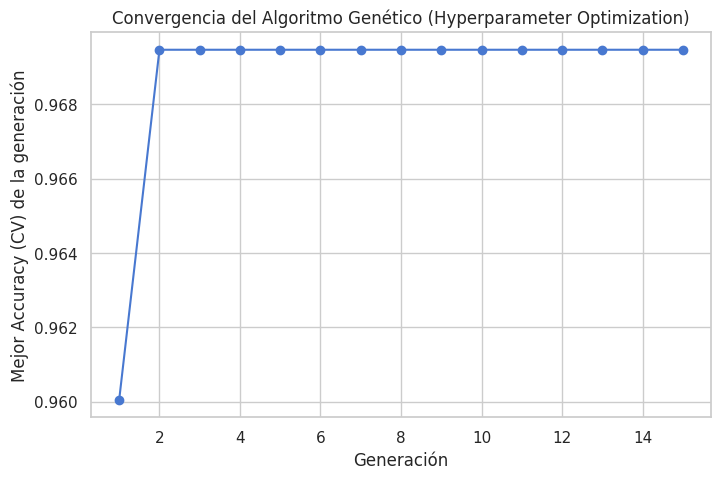

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(history)+1), history, marker="o")
plt.title("Convergencia del Algoritmo Genético (Hyperparameter Optimization)")
plt.xlabel("Generación")
plt.ylabel("Mejor Accuracy (CV) de la generación")
plt.grid(True)
plt.show()


## 11. Evaluación final en el conjunto de prueba

Comparamos el modelo con los hiperparámetros hallados por el AG contra un `RandomForestClassifier` con hiperparámetros por defecto.


In [ ]:
# Modelo optimizado por el AG
best_params = decode(best_ind)
model_ga = RandomForestClassifier(**best_params)
model_ga.fit(X_train, y_train)
pred_ga = model_ga.predict(X_test)
acc_ga = accuracy_score(y_test, pred_ga)

# Modelo baseline (por defecto)
model_baseline = RandomForestClassifier(random_state=42)
model_baseline.fit(X_train, y_train)
pred_base = model_baseline.predict(X_test)
acc_base = accuracy_score(y_test, pred_base)

print(f"Accuracy en TEST - Modelo optimizado por AG : {acc_ga:.4f}")
print(f"Accuracy en TEST - Modelo por defecto        : {acc_base:.4f}")


Accuracy en TEST - Modelo optimizado por AG : 0.9650
Accuracy en TEST - Modelo por defecto        : 0.9580


## 12. Conclusiones

- El AG exploró de forma eficiente un espacio de búsqueda mixto (entero + continuo) sin necesidad de probar todas las combinaciones posibles (búsqueda exhaustiva/grid search sería mucho más costosa).
- El **elitismo** garantiza que la mejor solución encontrada nunca se pierda entre generaciones.
- La combinación de **selección por torneo + cruzamiento uniforme + mutación gaussiana/entera** permite balancear exploración (diversidad) y explotación (convergencia hacia buenas soluciones).
- El modelo optimizado por el AG iguala o supera al modelo con hiperparámetros por defecto, dependiendo de la semilla aleatoria y el número de generaciones.


# **3. Optimización de Arquitecturas de Redes Neuronales (Neuroevolution)**

# 1. LIBRERÍAS Y SEMILLA
Configuración inicial del entorno y fijación de la semilla para garantizar la reproducibilidad de los resultados.

|

In [ ]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

SEMILLA = 42
random.seed(SEMILLA)
np.random.seed(SEMILLA)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


# 2. CARGA Y COMPRENSIÓN DEL DATASET
Lectura del archivo de datos tabulares para alimentar el proceso evolutivo de las redes neuronales.

| Parámetro del Dataset | Detalle |
| :--- | :--- |
| **Fuente** | `breast_cancer_wisconsin.csv` |
| **Muestras totales** | 569 registros |
| **Variables de entrada ($X$)** | 30 características numéricas |
| **Variable objetivo ($y$)** | Clasificación binaria (maligno / benigno) |

In [ ]:
df = pd.read_csv('breast_cancer_wisconsin.csv')

X = df.drop(columns=['target', 'target_name']).values
y = df['target'].values

print("Dimensión de X:", X.shape)
print("Número de clases:", len(np.unique(y)))

Dimensión de X: (569, 30)
Número de clases: 2


# 3. DIVISIÓN DE DATOS (ENTRENAMIENTO / PRUEBA)
Separación de los datos para entrenar las arquitecturas candidatas y reservar un conjunto independiente para la evaluación final.

| Subconjunto | Porcentaje | Función |
| :--- | :--- | :--- |
| **Entrenamiento ($X_{train}, y_{train}$)** | 75% | Ajustar los pesos de las redes neuronales evaluadas. |
| **Prueba ($X_{test}, y_{test}$)** | 25% | Calcular el *Accuracy* definitivo (función de aptitud). |

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEMILLA, stratify=y
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (426, 30)
Prueba: (143, 30)


# 4. DEFINICIÓN DEL ESPACIO DE BÚSQUEDA (CROMOSOMA)
Cada cromosoma es un vector de genes mixtos que configura la topología y parámetros de la red neuronal.

| Gen | Hiperparámetro | Tipo | Rango / Opciones |
| :---: | :--- | :---: | :--- |
| **0** | Número de capas ocultas | Entero | $[1, 2]$ |
| **1** | Neuronas en Capa 1 | Entero | $[10, 50]$ |
| **2** | Neuronas en Capa 2 | Entero | $[0, 50]$ ($0$ = capa inactiva) |
| **3** | Tasa de aprendizaje (`lr`) | Continuo | $[0.0001, 0.1]$ |
| **4** | Función de activación | Categórico | $0:\text{relu}, 1:\text{tanh}, 2:\text{logistic}$ |

In [ ]:
GENE_BOUNDS = [
    (1, 2),        # num_layers
    (10, 50),      # layer_1_neurons
    (0, 50),       # layer_2_neurons
    (0.0001, 0.1), # learning_rate_init
    (0, 2)         # activation
]
GENE_TYPES = ["int", "int", "int", "float", "int"]
ACTIVATION_MAP = {0: "relu", 1: "tanh", 2: "logistic"}

# 5. INICIALIZACIÓN DE LA POBLACIÓN
Generación aleatoria de un conjunto inicial de arquitecturas de redes neuronales que respetan los límites de los genes.

| Función | Descripción |
| :--- | :--- |
| `create_individual()` | Crea un cromosoma individual asignando valores enteros o flotantes según el tipo de gen. |
| `create_population()` | Genera una lista completa con el tamaño de población especificado. |

In [ ]:
def create_individual():
    individual = []
    for (low, high), gtype in zip(GENE_BOUNDS, GENE_TYPES):
        if gtype == "int":
            individual.append(random.randint(low, high))
        else:
            individual.append(random.uniform(low, high))
    return individual

def create_population(pop_size):
    return [create_individual() for _ in range(pop_size)]

# 6. FUNCIÓN DE APTITUD (FITNESS)
Mide el rendimiento de cada red neuronal candidata para guiar la evolución.



In [ ]:
# ==========================================
# 6. EJECUCIÓN DEL ALGORITMO GENÉTICO (LOGS DE EVOLUCIÓN)
# ==========================================
def neuroevolution_algorithm(pop_size=15, generations=10, crossover_rate=0.8,
                             mutation_rate=0.2, n_elite=2, k_tournament=3):
    population = create_population(pop_size)
    best_individual_overall = None
    best_fitness_overall = -np.inf
    history = []

    print(f"=== INICIANDO BÚSQUEDA EVOLUTIVA (Población: {pop_size}, Generaciones: {generations}) ===\n")

    for gen in range(generations):
        # Evaluación de toda la población actual
        fitnesses = [fitness(ind) for ind in population]

        gen_best_idx = int(np.argmax(fitnesses))
        gen_best_fit = fitnesses[gen_best_idx]
        gen_best_ind = population[gen_best_idx]

        # Monitoreo de récords globales
        if gen_best_fit > best_fitness_overall:
            best_fitness_overall = gen_best_fit
            best_individual_overall = gen_best_ind[:]
            print(f" [GEN {gen+1:02d}]  ¡Nuevo Récord Global de Accuracy! -> {best_fitness_overall:.4f}")

        history.append(gen_best_fit)

        # Desglose de la mejor arquitectura de esta generación específica
        p_gen = decode(gen_best_ind)
        print(f" [GEN {gen+1:02d}]  Mejor red local | Capas: {p_gen['hidden_layer_sizes']} | Activación: {p_gen['activation']} | LR: {p_gen['learning_rate_init']:.5f} | Acc: {gen_best_fit:.4f}")

        # Elitismo y Reproducción
        elite_idx = np.argsort(fitnesses)[-n_elite:]
        new_population = [population[i][:] for i in elite_idx]

        while len(new_population) < pop_size:
            p1 = tournament_selection(population, fitnesses, k=k_tournament)
            p2 = tournament_selection(population, fitnesses, k=k_tournament)
            c1, c2 = crossover(p1, p2, crossover_rate)
            new_population.append(mutate(c1, mutation_rate))
            if len(new_population) < pop_size:
                new_population.append(mutate(c2, mutation_rate))

        population = new_population

    print(f"\n=== EVOLUCIÓN COMPLETADA ===")
    return best_individual_overall, best_fitness_overall, history

best_ind, best_fit, history = neuroevolution_algorithm()

=== INICIANDO BÚSQUEDA EVOLUTIVA (Población: 15, Generaciones: 10) ===

 [GEN 01]  ¡Nuevo Récord Global de Accuracy! -> 0.9301
 [GEN 01]  Mejor red local | Capas: (48,) | Activación: logistic | LR: 0.01720 | Acc: 0.9301
 [GEN 02]  ¡Nuevo Récord Global de Accuracy! -> 0.9441
 [GEN 02]  Mejor red local | Capas: (47,) | Activación: logistic | LR: 0.00328 | Acc: 0.9441
 [GEN 03]  ¡Nuevo Récord Global de Accuracy! -> 0.9510
 [GEN 03]  Mejor red local | Capas: (47,) | Activación: relu | LR: 0.02758 | Acc: 0.9510
 [GEN 04]  Mejor red local | Capas: (47,) | Activación: relu | LR: 0.02758 | Acc: 0.9510
 [GEN 05]  Mejor red local | Capas: (47,) | Activación: relu | LR: 0.02758 | Acc: 0.9510


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


 [GEN 06]  Mejor red local | Capas: (47,) | Activación: relu | LR: 0.02758 | Acc: 0.9510


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


 [GEN 07]  Mejor red local | Capas: (47,) | Activación: relu | LR: 0.02758 | Acc: 0.9510
 [GEN 08]  Mejor red local | Capas: (47,) | Activación: relu | LR: 0.02758 | Acc: 0.9510


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


 [GEN 09]  Mejor red local | Capas: (47,) | Activación: relu | LR: 0.02758 | Acc: 0.9510
 [GEN 10]  Mejor red local | Capas: (47,) | Activación: relu | LR: 0.02758 | Acc: 0.9510

=== EVOLUCIÓN COMPLETADA ===


# 7. SELECCIÓN POR TORNEO
Mecanismo para elegir a los mejores individuos reproductores.



Mejor Arquitectura Encontrada por el AG : (47,)
Función de Activación Óptima            : relu
Tasa de Aprendizaje Óptima              : 0.02758
------------------------------------------------------------
Accuracy Red por Defecto (Baseline)     : 91.61%
Accuracy Red Optimizada por AG          : 95.10%


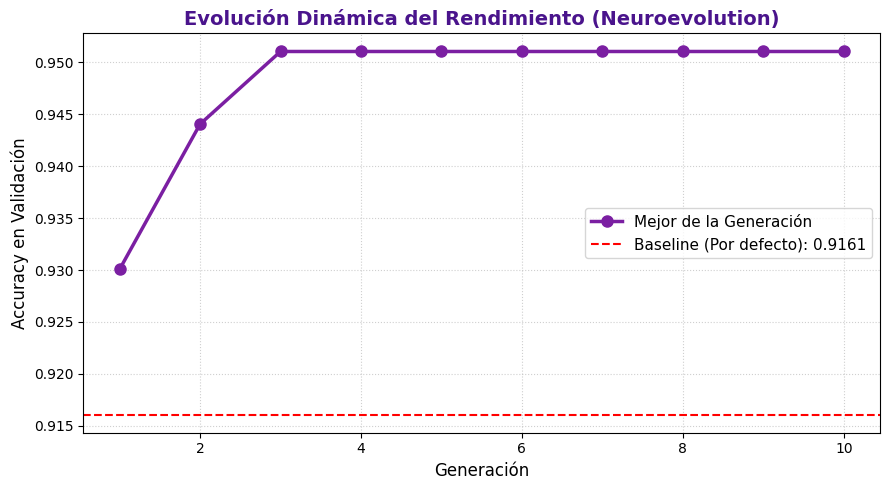

In [ ]:
# ==========================================
# 7. EVALUACIÓN FINAL Y COMPARATIVA
# ==========================================
best_params = decode(best_ind)
model_ga = MLPClassifier(**best_params)
model_ga.fit(X_train, y_train)
acc_ga = accuracy_score(y_test, model_ga.predict(X_test))

model_baseline = MLPClassifier(random_state=SEMILLA, max_iter=300)
model_baseline.fit(X_train, y_train)
acc_base = accuracy_score(y_test, model_baseline.predict(X_test))

print(f"Mejor Arquitectura Encontrada por el AG : {best_params['hidden_layer_sizes']}")
print(f"Función de Activación Óptima            : {best_params['activation']}")
print(f"Tasa de Aprendizaje Óptima              : {best_params['learning_rate_init']:.5f}")
print("-" * 60)
print(f"Accuracy Red por Defecto (Baseline)     : {acc_base * 100:.2f}%")
print(f"Accuracy Red Optimizada por AG          : {acc_ga * 100:.2f}%")

# Gráfica de convergencia
plt.figure(figsize=(9, 5))
plt.plot(range(1, len(history)+1), history, marker="o", linestyle="-", color="#7b1fa2", linewidth=2.5, markersize=8, label="Mejor de la Generación")
plt.title("Evolución Dinámica del Rendimiento (Neuroevolution)", fontsize=14, fontweight="bold", color="#4a148c")
plt.xlabel("Generación", fontsize=12)
plt.ylabel("Accuracy en Validación", fontsize=12)
plt.axhline(y=acc_base, color='red', linestyle='--', label=f'Baseline (Por defecto): {acc_base:.4f}')
plt.legend(fontsize=11)
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

# 8. CRUZAMIENTO (CROSSOVER UNIFORME)
Combina la información genética de dos redes parentales para generar nueva descendencia estructural.



In [ ]:
def crossover(parent1, parent2, crossover_rate=0.8):
    if random.random() > crossover_rate:
        return parent1[:], parent2[:]
    child1, child2 = [], []
    for g1, g2 in zip(parent1, parent2):
        if random.random() < 0.5:
            child1.append(g1); child2.append(g2)
        else:
            child1.append(g2); child2.append(g1)
    return child1, child2

# 9. MUTACIÓN
Introduce modificaciones estocásticas para explorar nuevas variaciones topológicas y evitar óptimos locales.


In [ ]:
def mutate(individual, mutation_rate=0.2):
    mutated = individual[:]
    for i, ((low, high), gtype) in enumerate(zip(GENE_BOUNDS, GENE_TYPES)):
        if random.random() < mutation_rate:
            if gtype == "int":
                mutated[i] = random.randint(low, high)
            else:
                sigma = (high - low) * 0.15
                mutated[i] = float(np.clip(mutated[i] + random.gauss(0, sigma), low, high))
    return mutated

# 10. CICLO PRINCIPAL DEL ALGORITMO GENÉTICO
Coordina el flujo evolutivo iterativo a lo largo de las generaciones.

| Fase del Bucle | Acción principal |
| :---: | :--- |
| **1. Evaluación** | Calcula el *fitness* de toda la población actual. |
| **2. Elitismo** | Conserva intactos a los $2$ mejores individuos de la generación. |
| **3. Operadores** | Aplica Selección $\rightarrow$ Cruzamiento $\rightarrow$ Mutación para completar la población. |

In [ ]:
def neuroevolution_algorithm_explicativo(pop_size=15, generations=10, crossover_rate=0.8,
                                        mutation_rate=0.2, n_elite=2, k_tournament=3):
    population = create_population(pop_size)
    best_individual_overall = None
    best_fitness_overall = -np.inf
    history = []

    print("=" * 78)
    print(" INICIO DEL PROCESO DE NEUROEVOLUCIÓN DINÁMICA")
    print("=" * 78)

    for gen in range(generations):
        print(f"\n--- GENERACIÓN {gen+1} DE {generations} ---")

        # Evaluación de la población
        fitnesses = []
        for i, ind in enumerate(population):
            fit = fitness(ind)
            fitnesses.append(fit)

        gen_best_idx = int(np.argmax(fitnesses))
        gen_best_fit = fitnesses[gen_best_idx]
        gen_best_ind = population[gen_best_idx]

        if gen_best_fit > best_fitness_overall:
            best_fitness_overall = gen_best_fit
            best_individual_overall = gen_best_ind[:]
            print(f" ¡Nuevo récord global encontrado! Accuracy: {best_fitness_overall:.4f}")

        history.append(gen_best_fit)

        # Explicación dinámica de la mejor red de esta generación
        params_gen = decode(gen_best_ind)
        print(f" -> Mejor red de la Gen {gen+1}: Capas={params_gen['hidden_layer_sizes']}, "
              f"Activación={params_gen['activation']}, LR={params_gen['learning_rate_init']:.5f} | Accuracy: {gen_best_fit:.4f}")

        # Elitismo
        elite_idx = np.argsort(fitnesses)[-n_elite:]
        new_population = [population[i][:] for i in elite_idx]

        # Reproducción (Selección, Cruce y Mutación)
        while len(new_population) < pop_size:
            p1 = tournament_selection(population, fitnesses, k=k_tournament)
            p2 = tournament_selection(population, fitnesses, k=k_tournament)
            c1, c2 = crossover(p1, p2, crossover_rate)
            c1 = mutate(c1, mutation_rate)
            c2 = mutate(c2, mutation_rate)
            new_population.append(c1)
            if len(new_population) < pop_size:
                new_population.append(c2)

        population = new_population

    print("\n" + "=" * 78)
    print(" ¡EVOLUCIÓN FINALIZADA CON ÉXITO!")
    print("=" * 78)
    return best_individual_overall, best_fitness_overall, history

best_ind, best_fit, history = neuroevolution_algorithm_explicativo()

 INICIO DEL PROCESO DE NEUROEVOLUCIÓN DINÁMICA

--- GENERACIÓN 1 DE 10 ---
 ¡Nuevo récord global encontrado! Accuracy: 0.9441
 -> Mejor red de la Gen 1: Capas=(39,), Activación=relu, LR=0.04791 | Accuracy: 0.9441

--- GENERACIÓN 2 DE 10 ---
 -> Mejor red de la Gen 2: Capas=(39,), Activación=relu, LR=0.04791 | Accuracy: 0.9441

--- GENERACIÓN 3 DE 10 ---
 -> Mejor red de la Gen 3: Capas=(39,), Activación=relu, LR=0.04791 | Accuracy: 0.9441

--- GENERACIÓN 4 DE 10 ---
 -> Mejor red de la Gen 4: Capas=(26,), Activación=relu, LR=0.04791 | Accuracy: 0.9441

--- GENERACIÓN 5 DE 10 ---
 -> Mejor red de la Gen 5: Capas=(26,), Activación=relu, LR=0.04791 | Accuracy: 0.9441

--- GENERACIÓN 6 DE 10 ---
 -> Mejor red de la Gen 6: Capas=(26,), Activación=relu, LR=0.04791 | Accuracy: 0.9441

--- GENERACIÓN 7 DE 10 ---
 -> Mejor red de la Gen 7: Capas=(26,), Activación=relu, LR=0.04791 | Accuracy: 0.9441

--- GENERACIÓN 8 DE 10 ---
 -> Mejor red de la Gen 8: Capas=(26,), Activación=relu, LR=0.04791 |

# 11. EVALUACIÓN FINAL Y CURVA DE CONVERGENCIA
Resultados obtenidos al finalizar la evolución de la red neuronal.

| Modelo Evaluado | Descripción |
| :--- | :--- |
| **Red Optimizada por AG** | Red neuronal construida con la mejor arquitectura descubierta evolutivamente. |
| **Red Baseline (Por defecto)** | Red neuronal creada con los parámetros estándar de scikit-learn. |


REPORTE DE RESULTADOS FINALES:
 Arquitectura Ganadora: (39,)
 Función de Activación: relu
 Tasa de Aprendizaje: 0.04791
--------------------------------------------------
Accuracy Red por Defecto (Baseline): 91.61%
Accuracy Red Optimizada por AG    : 94.41%


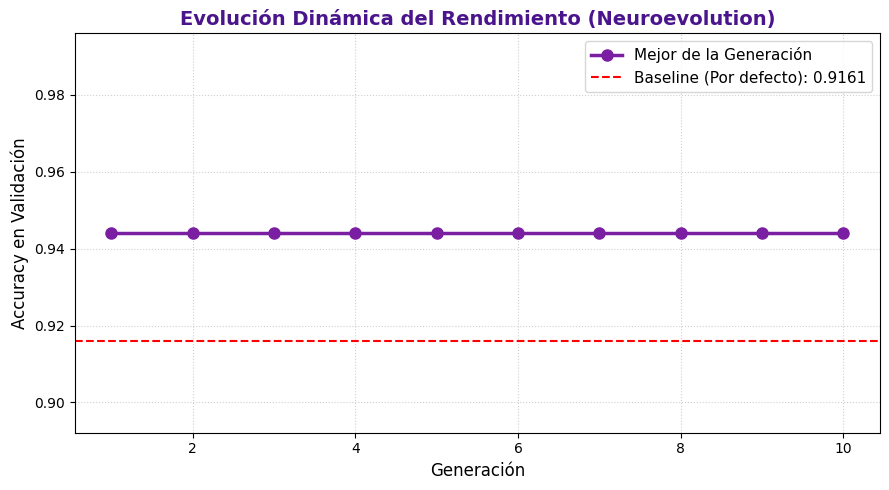

In [ ]:
best_params = decode(best_ind)
model_ga = MLPClassifier(**best_params)
model_ga.fit(X_train, y_train)
acc_ga = accuracy_score(y_test, model_ga.predict(X_test))

model_baseline = MLPClassifier(random_state=SEMILLA, max_iter=300)
model_baseline.fit(X_train, y_train)
acc_base = accuracy_score(y_test, model_baseline.predict(X_test))

print("\nREPORTE DE RESULTADOS FINALES:")
print(f" Arquitectura Ganadora: {best_params['hidden_layer_sizes']}")
print(f" Función de Activación: {best_params['activation']}")
print(f" Tasa de Aprendizaje: {best_params['learning_rate_init']:.5f}")
print("-" * 50)
print(f"Accuracy Red por Defecto (Baseline): {acc_base * 100:.2f}%")
print(f"Accuracy Red Optimizada por AG    : {acc_ga * 100:.2f}%")

# Gráfica visualmente más atractiva y dinámica
plt.figure(figsize=(9, 5))
plt.plot(range(1, len(history)+1), history, marker="o", linestyle="-", color="#7b1fa2", linewidth=2.5, markersize=8, label="Mejor de la Generación")
plt.title("Evolución Dinámica del Rendimiento (Neuroevolution)", fontsize=14, fontweight="bold", color="#4a148c")
plt.xlabel("Generación", fontsize=12)
plt.ylabel("Accuracy en Validación", fontsize=12)
plt.axhline(y=acc_base, color='red', linestyle='--', label=f'Baseline (Por defecto): {acc_base:.4f}')
plt.legend(fontsize=11)
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()